## **Clustering Case: Bangladesh Crime (Notebook)**

### **0. Setup**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rapidfuzz import process, fuzz
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

In [2]:
RANDOM_STATE = 42
K_RANGE = range(2,11)
PALETTE = ['#7c3aed', '#0ea5e9', '#10b981', '#f59e0b', '#ef4444', "#f65cee", '#06b6d4', '#84cc16']

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
print("~ Setup Completely ~")

~ Setup Completely ~


In [3]:
df_raw = pd.read_csv('Bangladesh Crime.csv', delimiter=',')
df = df_raw.copy()
df.tail()

,Unnamed: 0,incident_month,incident_week,incident_weekday,weekend,part_of_the_day,incident_district,incident_division,precip,visibility,heatindex,season,male_population,female_population,total_population,gender_ration,average_household_size,density_per_kmsq,literacy_rate,religious_institution,playground,park,police_station,school,college,crime
6569,6569,3,10,tuesday,0,night,munshiganj,dhaka,8.5000,9,27,hot,98120,99053,197173,99,4.5500,1399,57.1000,365,27,0,1,17,3,robbery
6570,6570,10,42,saturday,1,night,munshiganj,dhaka,2.6000,10,32,rainy,98120,99053,197173,99,4.5500,1399,57.1000,365,27,0,1,17,3,robbery
6571,6571,3,10,tuesday,0,night,munshiganj,dhaka,NaN,9,27,hot,98120,99053,197173,99,4.5500,1399,57.1000,365,27,0,1,17,3,robbery
6572,6572,1,2,wednesday,0,night,sylhet,sylhet,0.0000,10,17,winter,117354,119783,237137,98,5.8200,893,49.4000,359,1,0,1,19,3,robbery
6573,6573,1,4,tuesday,0,night,pirojpur,barisal,0.0000,10,21,winter,37947,39270,77217,97,4.4400,816,61.2000,286,12,0,2,12,2,robbery


In [4]:
print(f"This dataset contains {df.shape[0]} Rows and {df.shape[1]} Columns with {df.memory_usage(deep=True).sum()/1e6:.2f} MB")

This dataset contains 6574 Rows and 26 Columns with 3.55 MB


In [5]:
df.info()
df.describe(include='all').T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6574 entries, 0 to 6573
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              6574 non-null   int64  
 1   incident_month          6574 non-null   int64  
 2   incident_week           6574 non-null   int64  
 3   incident_weekday        6574 non-null   object 
 4   weekend                 6574 non-null   int64  
 5   part_of_the_day         6457 non-null   object 
 6   incident_district       6574 non-null   object 
 7   incident_division       6574 non-null   object 
 8   precip                  5917 non-null   float64
 9   visibility              6574 non-null   int64  
 10  heatindex               6574 non-null   int64  
 11  season                  6246 non-null   object 
 12  male_population         6574 non-null   int64  
 13  female_population       6574 non-null   int64  
 14  total_population        6574 non-null   

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,6574.0000,NaN,NaN,NaN,3286.5000,1897.8947,0.0000,1643.2500,3286.5000,4929.7500,6573.0000
incident_month,6574.0000,NaN,NaN,NaN,6.1932,3.3219,1.0000,3.0000,6.0000,9.0000,12.0000
incident_week,6574.0000,NaN,NaN,NaN,25.1939,14.5180,1.0000,13.0000,25.0000,37.0000,53.0000
incident_weekday,6574,400,tuesday,912,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weekend,6574.0000,NaN,NaN,NaN,0.2738,0.4459,0.0000,0.0000,0.0000,1.0000,1.0000
part_of_the_day,6457,5,night,3179,NaN,NaN,NaN,NaN,NaN,NaN,NaN
incident_district,6574,64,dhaka,1169,NaN,NaN,NaN,NaN,NaN,NaN,NaN
incident_division,6574,9,dhaka,2046,NaN,NaN,NaN,NaN,NaN,NaN,NaN
precip,5917.0000,NaN,NaN,NaN,6.1368,11.7783,0.0000,0.0000,0.8000,7.4000,204.6000
visibility,6574.0000,NaN,NaN,NaN,9.4883,0.9227,4.0000,9.0000,10.0000,10.0000,10.0000


### **1. Data Preprocessing and Cleaning**

In [6]:
DROP_COLS = ['Unnamed: 0', 'incident_district', 'male_population', 'female_population']
df.drop(columns=DROP_COLS, inplace=True)
print(f"This dataset contains {df.shape[1]} Columns now.")

This dataset contains 22 Columns now.


In [7]:
NUM_FEATURES = ['incident_month', 'incident_week', 'precip', 'visibility', 'heatindex',
                'total_population', 'gender_ration', 'average_household_size', 'density_per_kmsq',
                'literacy_rate', 'religious_institution', 'playground', 'park', 'police_station',
                'school', 'college']
CAT_FEATURES = ['part_of_the_day', 'incident_weekday', 'incident_division', 'season']
BIN_FEATURES = ['weekend']

In [8]:
missing_df = pd.DataFrame({
    'count' : df.isna().sum(),
    'pct (%)' : df.isna().mean().mul(100).round(2)
}).query('count > 0').sort_values('pct (%)', ascending=False)
display(missing_df)

,count,pct (%)
precip,657,9.9900
season,328,4.9900
literacy_rate,328,4.9900
part_of_the_day,117,1.7800


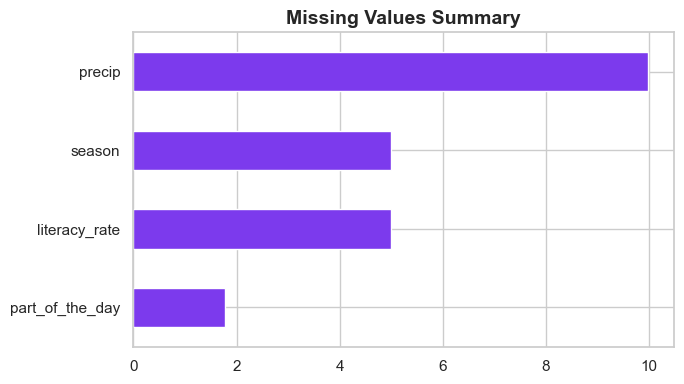

In [9]:
if not missing_df.empty:
    missing_df['pct (%)'].plot(kind='barh', figsize=(7,4), color=PALETTE[0])
    plt.title('Missing Values Summary', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

In [10]:
df['precip'] = df['precip'].fillna(df['precip'].median())
df['season'] = df['season'].fillna(df['season'].mode()[0])
df['literacy_rate'] = df['literacy_rate'].fillna(df['literacy_rate'].median())
df.dropna(subset=['part_of_the_day'], inplace=True)
print(f"Missing values now: {df.isna().sum().sum()} | Rows remaining: {len(df)}")

Missing values now: 0 | Rows remaining: 6457


In [11]:
duplicates = df.duplicated().sum()
print(f"Duplicates: {duplicates} ({duplicates/len(df)*100:.2f}%)")

Duplicates: 290 (4.49%)


In [12]:
df.drop_duplicates(inplace=True)
print(f"Duplicates now: {df.duplicated().sum()} | Rows remaining: {len(df)}")

Duplicates now: 0 | Rows remaining: 6167


In [13]:
df['incident_weekday'].value_counts(ascending=False)

CORRECT_DAYS = ['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday']
df['incident_weekday'] = df['incident_weekday'].str.lower().str.strip()
df['incident_weekday'] = df['incident_weekday'].apply(
    lambda x: process.extractOne(x, CORRECT_DAYS, scorer=fuzz.WRatio)[0]
    if process.extractOne(x, CORRECT_DAYS, scorer=fuzz.WRatio) is not None else x
)
print(df['incident_weekday'].value_counts(ascending=False))

incident_weekday
tuesday      938
wednesday    913
monday       913
thursday     896
saturday     858
friday       833
sunday       816
Name: count, dtype: int64


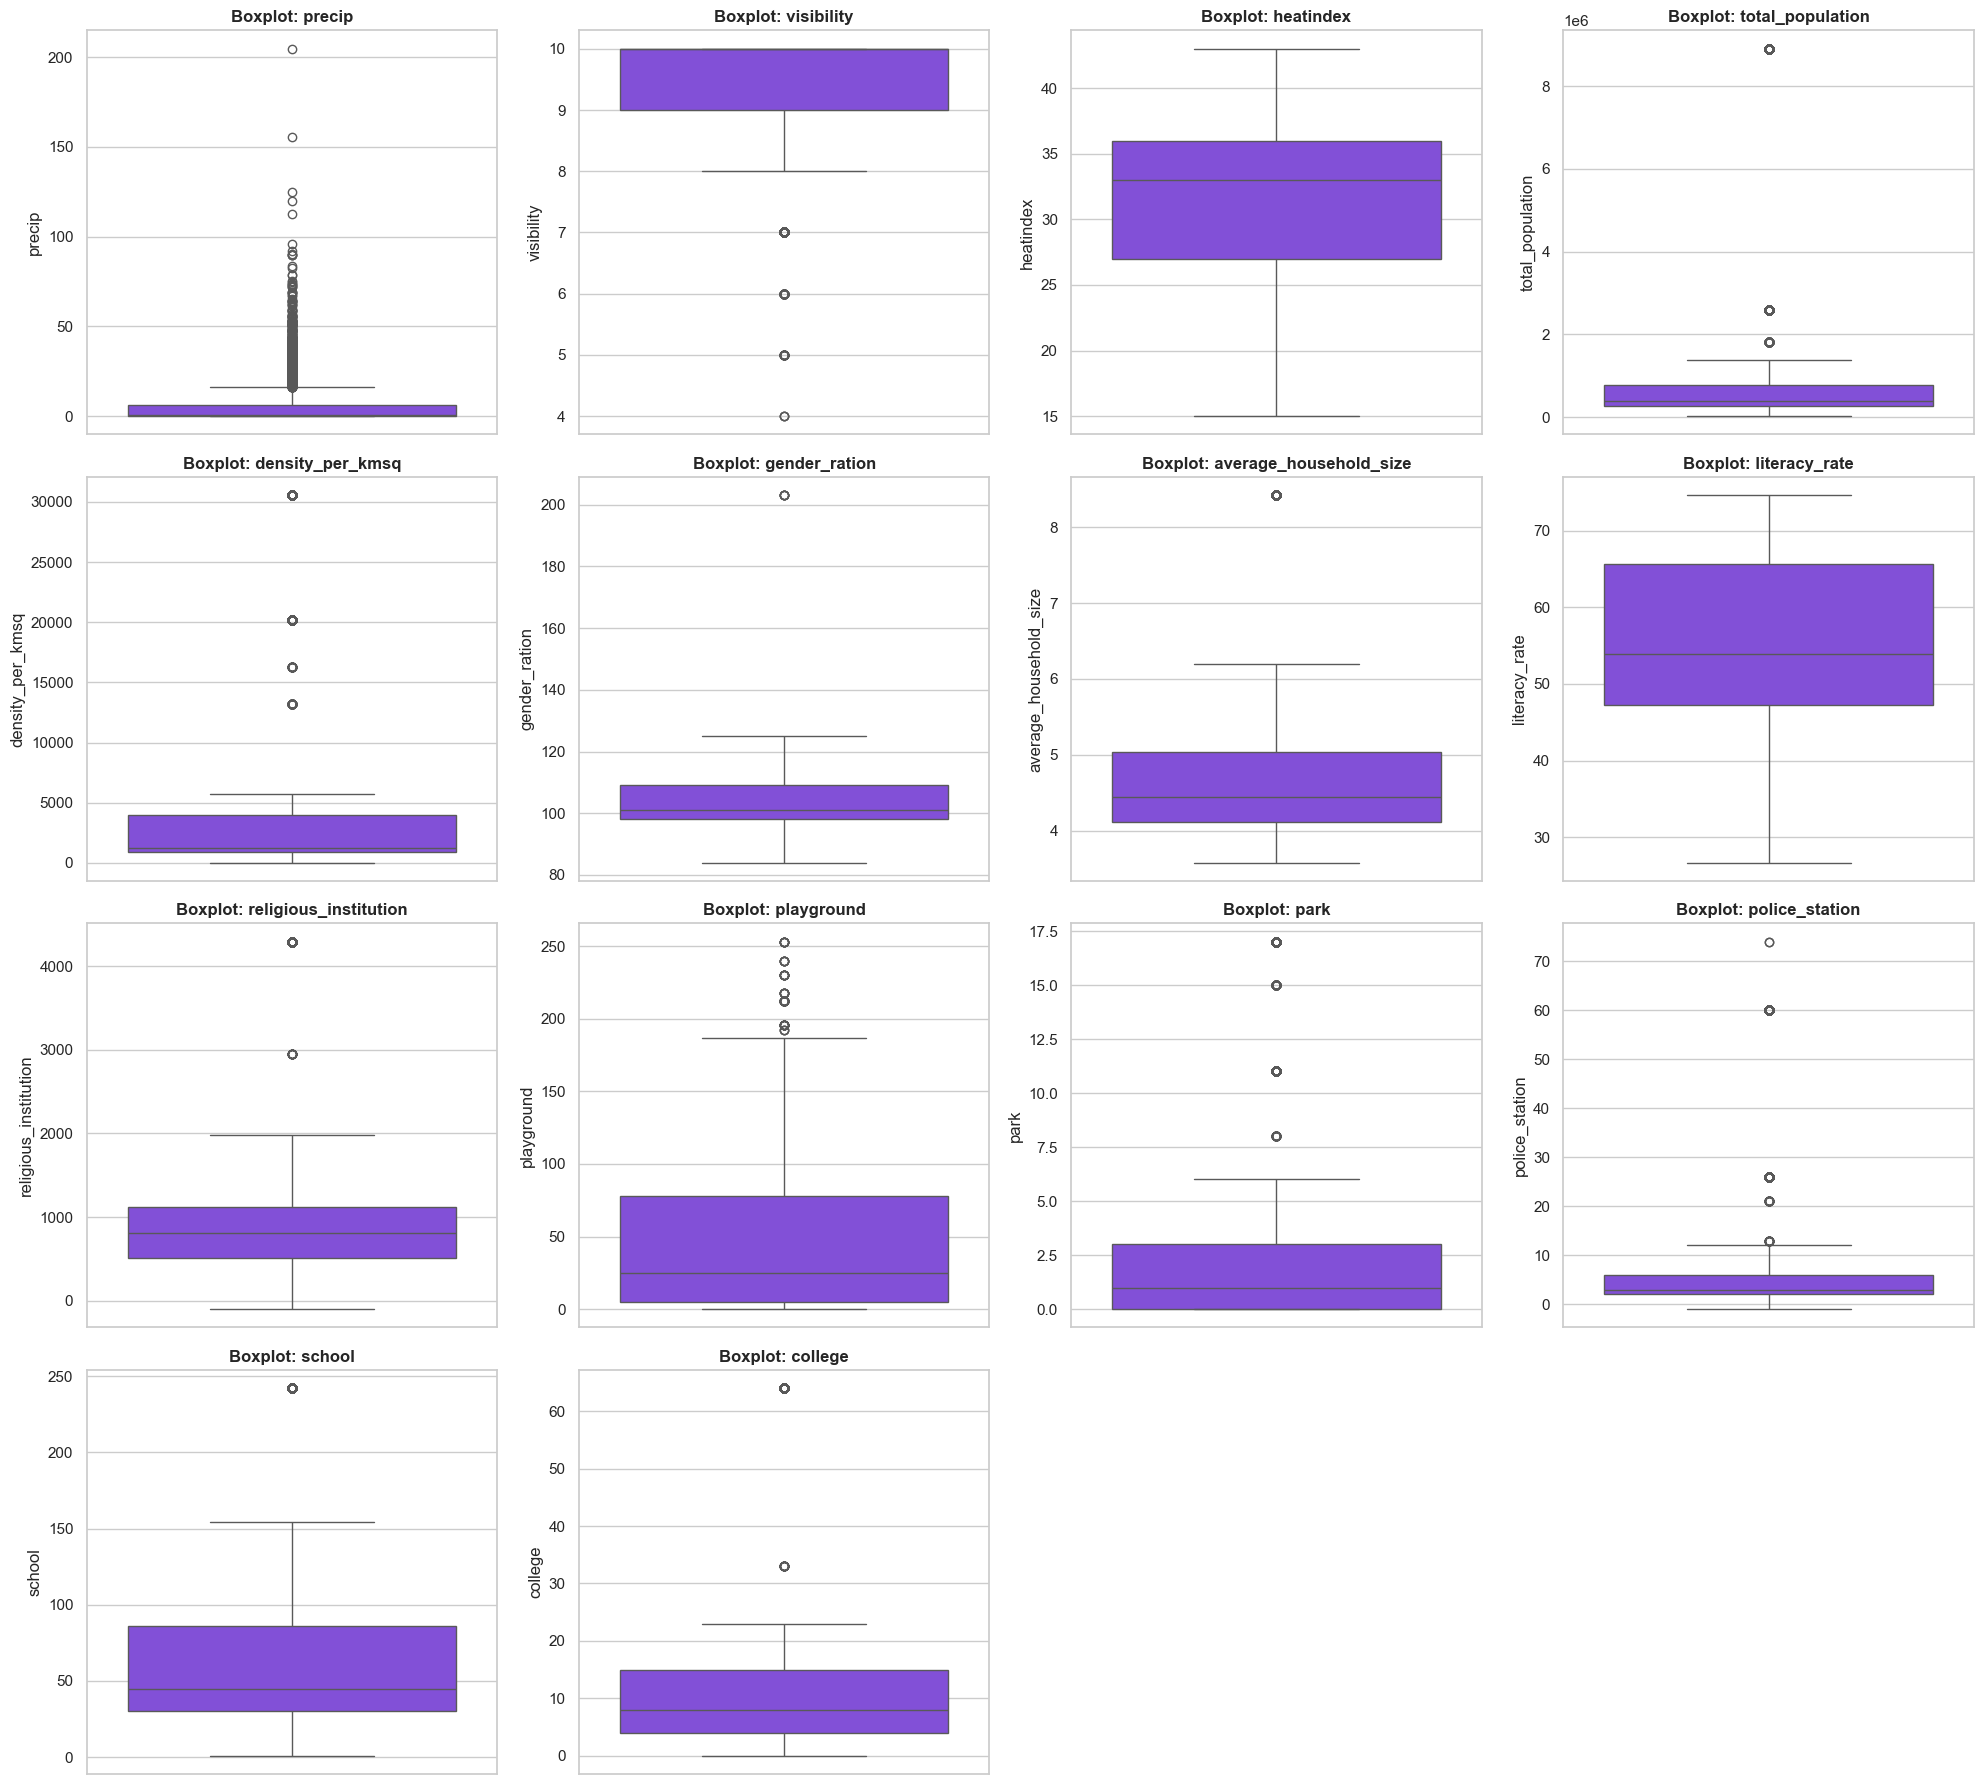

In [14]:
OUTLIER_COLS = ['precip', 'visibility', 'heatindex', 'total_population', 'density_per_kmsq',
                'gender_ration', 'average_household_size', 'literacy_rate', 'religious_institution', 
                'playground', 'park', 'police_station', 'school', 'college']

plt.figure(figsize=(20, 18))
for i, col in enumerate(OUTLIER_COLS, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(y=df[col], color=PALETTE[0])
    plt.title(f'Boxplot: {col}', fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
for col in OUTLIER_COLS:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f"{col:<30} | Outliers: {n_out}")

precip                         | Outliers: 728
visibility                     | Outliers: 303
heatindex                      | Outliers: 0
total_population               | Outliers: 1178
density_per_kmsq               | Outliers: 1193
gender_ration                  | Outliers: 6
average_household_size         | Outliers: 817
literacy_rate                  | Outliers: 0
religious_institution          | Outliers: 827
playground                     | Outliers: 86
park                           | Outliers: 1216
police_station                 | Outliers: 1148
school                         | Outliers: 817
college                        | Outliers: 839


In [16]:
CLIP_FLOOR_COLS = ['religious_institution', 'playground', 'police_station', 'park', 'school', 'college']
for col in CLIP_FLOOR_COLS:
    df[col] = df[col].clip(lower=0)

WINSORIZE_COLS = ['precip', 'total_population', 'gender_ration', 'average_household_size', 'density_per_kmsq']
for col in WINSORIZE_COLS:
    low, high = df[col].quantile(0.01), df[col].quantile(0.99)
    df[col] = df[col].clip(low, high)

print(f'Final shape after cleaning: {df.shape}')

Final shape after cleaning: (6167, 22)


### **2. EDA**

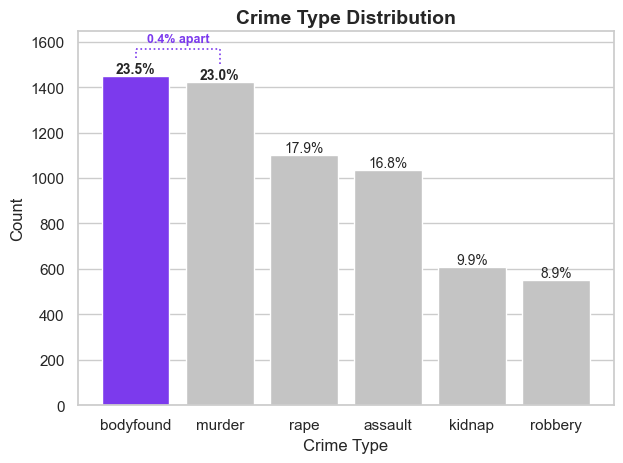

In [17]:
counts = df['crime'].value_counts(ascending=False)
ax = sns.countplot(x='crime', data=df, order=counts.index, color='#c4c4c4')
ax.patches[0].set_facecolor(PALETTE[0])

n = len(df)
for i, p in enumerate(ax.patches):
    ax.text(p.get_x() + p.get_width()/2, p.get_height(),
            f'{p.get_height()/n*100:.1f}%',
            ha='center', va='bottom', fontsize=10,
            fontweight='bold' if i < 2 else 'normal')

b0, b1 = counts.iloc[0], counts.iloc[1]
by = b0 + 120
for xs, ys in [([0,0], [b0+80,by]), ([0,1], [by,by]), ([1,1], [b1+80,by])]:
    ax.plot(xs, ys, color=PALETTE[0], lw=1.2, linestyle='dotted')
ax.text(0.5, by+20, f'{abs(b0-b1)/n*100:.1f}% apart',
        ha='center', va='bottom', fontsize=9, color=PALETTE[0], fontweight='bold')

plt.title('Crime Type Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Crime Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

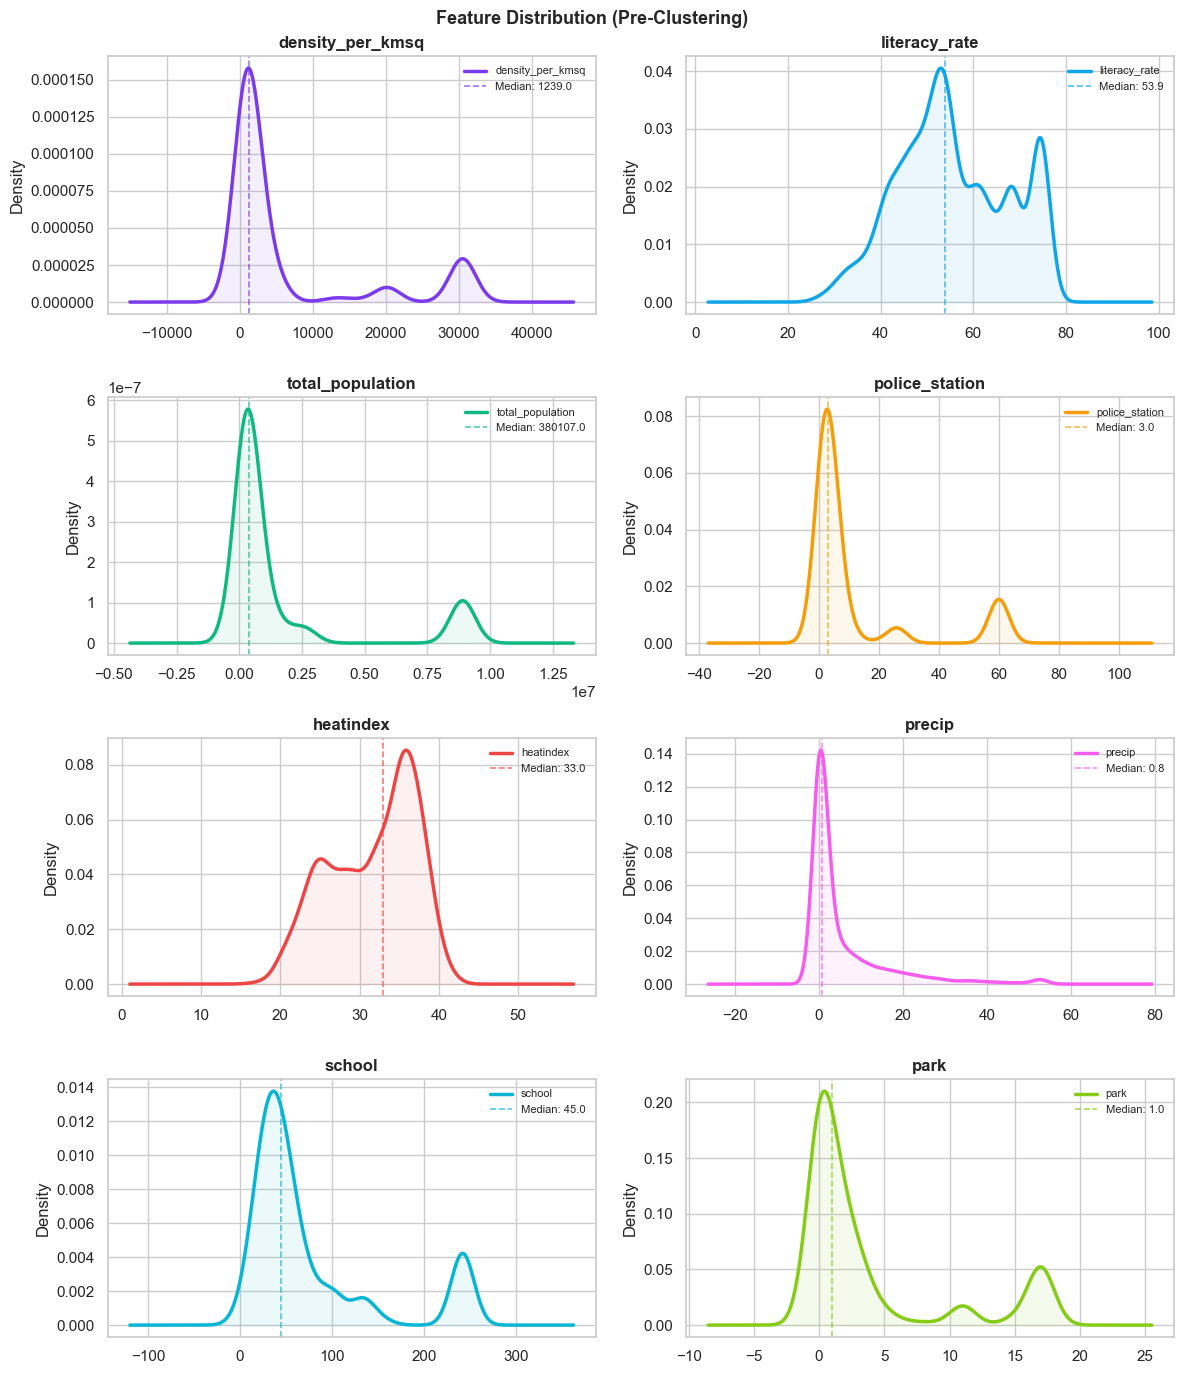

In [18]:
KDE_NUM = ['density_per_kmsq', 'literacy_rate', 'total_population',
           'police_station', 'heatindex', 'precip', 'school', 'park']

fig, axes = plt.subplots(4, 2, figsize=(12,14))
for ax, col, color in zip(axes.flatten(), KDE_NUM, PALETTE):
    data = df[col].dropna()
    med = data.median()
    data.plot(kind='kde', ax=ax, color=color, linewidth=2.5)
    ax.axvline(med, color=color, linestyle='--', linewidth=1.2, alpha=0.7, label=f'Median: {med:.1f}')
    ax.fill_between(ax.lines[0].get_xdata(), ax.lines[0].get_ydata(), alpha=0.08, color=color)
    ax.legend(fontsize=8, frameon=False)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('')

plt.suptitle("Feature Distribution (Pre-Clustering)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

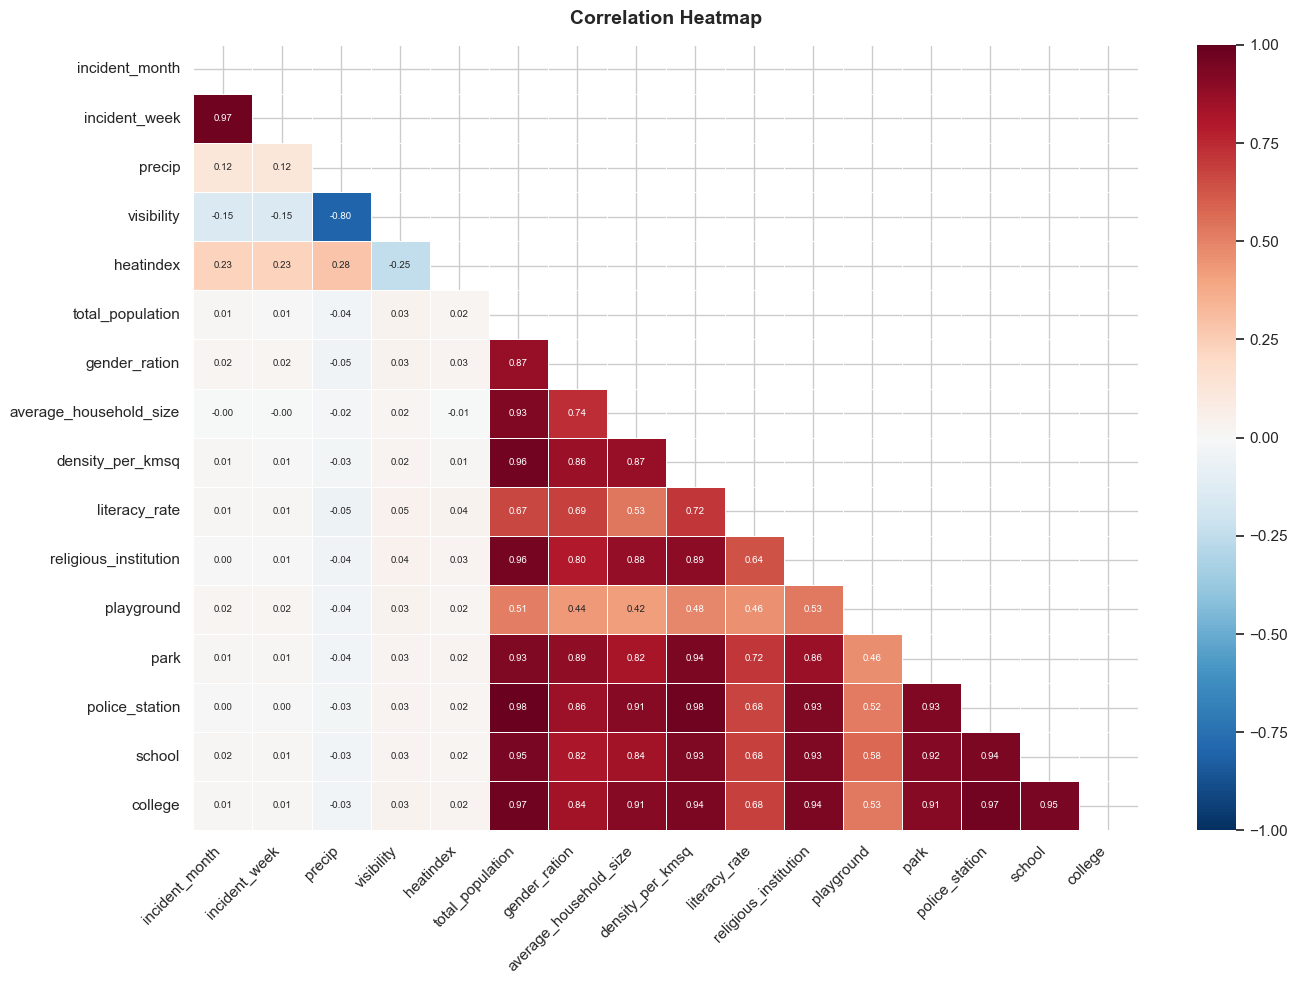

In [19]:
corr = df[NUM_FEATURES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14,10))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.4, annot_kws={'size':7})
plt.title("Correlation Heatmap", fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

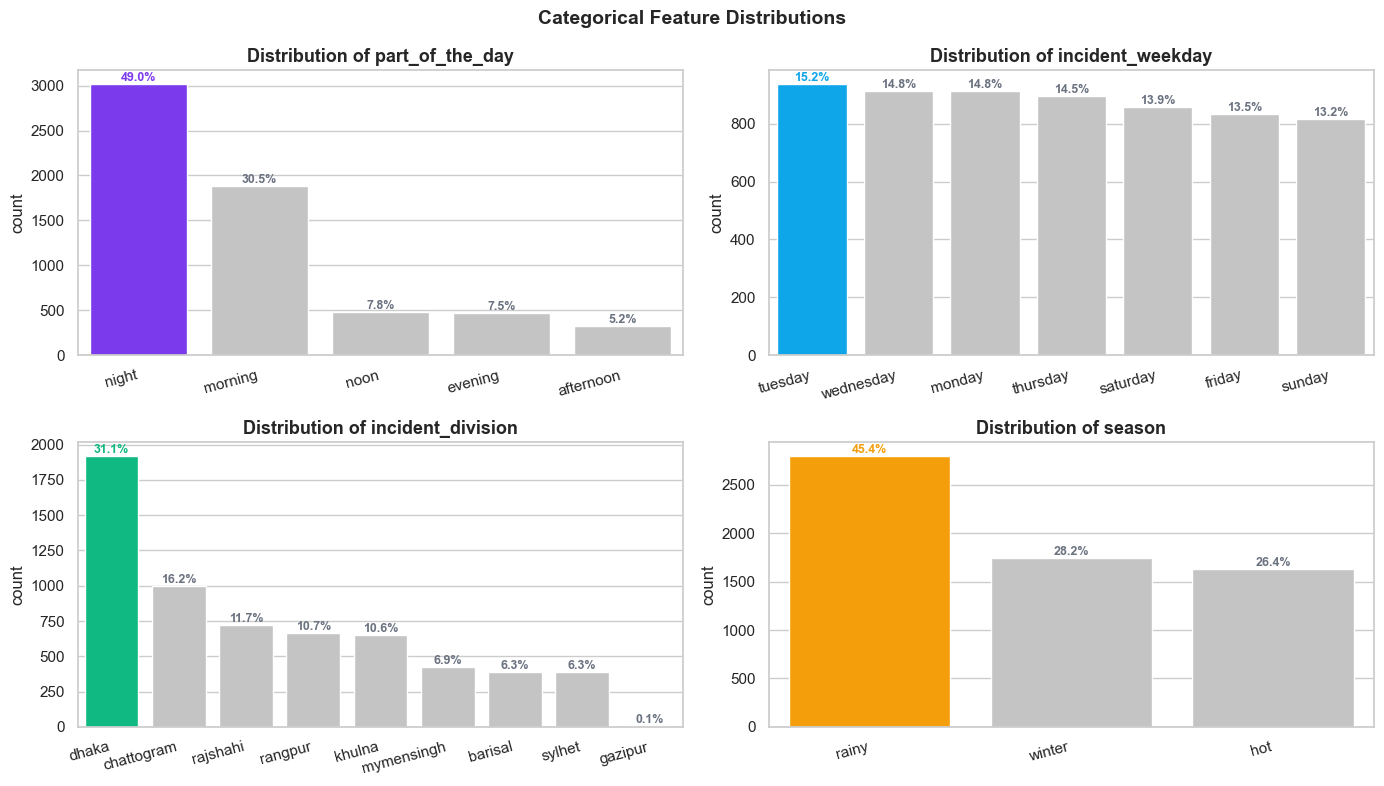

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14,8))
for ax, col, accent in zip(axes.flatten(), CAT_FEATURES, PALETTE[0:4]):
    counts = df[col].value_counts(ascending=False)
    sns.countplot(x=col, data=df, order=counts.index, color= '#c4c4c4', ax=ax)
    ax.patches[0].set_facecolor(accent)

    n = len(df)
    for i, p in enumerate(ax.patches):
        ax.text(p.get_x() + p.get_width()/2, p.get_height(),
                f'{p.get_height()/n*100:.1f}%',
                ha='center', va='bottom', fontsize=9, fontweight='bold',
                color=accent if i == 0 else '#6b7280')
    
    ax.set_title(f"Distribution of {col}", fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    plt.setp(ax.get_xticklabels(), rotation=15, ha='right')
plt.suptitle("Categorical Feature Distributions", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [21]:
num_transformer = Pipeline([
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, NUM_FEATURES + BIN_FEATURES),
    ('cat', cat_transformer, CAT_FEATURES),
], remainder='drop')

In [22]:
X = df[NUM_FEATURES + CAT_FEATURES + BIN_FEATURES]
X_processed = preprocessor.fit_transform(X)
print(f"Processed feature shape: {X_processed.shape}")

Processed feature shape: (6167, 41)


### **3. Optimal K-Selection + Modeling**

In [23]:
inertias, sil_scores, db_scores, ch_scores = [], [], [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=300, random_state=RANDOM_STATE)
    labels=km.fit_predict(X_processed)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_processed, labels))
    db_scores.append(davies_bouldin_score(X_processed, labels))
    ch_scores.append(calinski_harabasz_score(X_processed, labels))

k_list = list(K_RANGE)
print(f"{'K':<5} | {'Inertia':>12} | {'Silhouette':>12} | {'Davies-Bouldin':>16} | {'Calinski-Harabasz':>18}")
print('-' * 75)
for i, k in enumerate(k_list):
    results = f"{k:<5} | {inertias[i]:>12.2f} | {sil_scores[i]:>12.4f} | {db_scores[i]:>16.4f} | {ch_scores[i]:>18.2f}"
    print(results)

K     |      Inertia |   Silhouette |   Davies-Bouldin |  Calinski-Harabasz
---------------------------------------------------------------------------
2     |     71436.63 |       0.5113 |           0.7142 |            4469.62
3     |     60924.33 |       0.2141 |           1.6623 |            3151.78
4     |     54725.62 |       0.2230 |           1.6509 |            2571.50
5     |     50677.67 |       0.2075 |           1.7262 |            2205.39
6     |     47767.06 |       0.2099 |           1.7275 |            1946.60
7     |     45256.95 |       0.2028 |           1.6867 |            1768.80
8     |     43203.59 |       0.1890 |           1.7245 |            1629.73
9     |     41600.85 |       0.1559 |           1.7853 |            1510.37
10    |     40165.87 |       0.1604 |           1.7975 |            1414.73


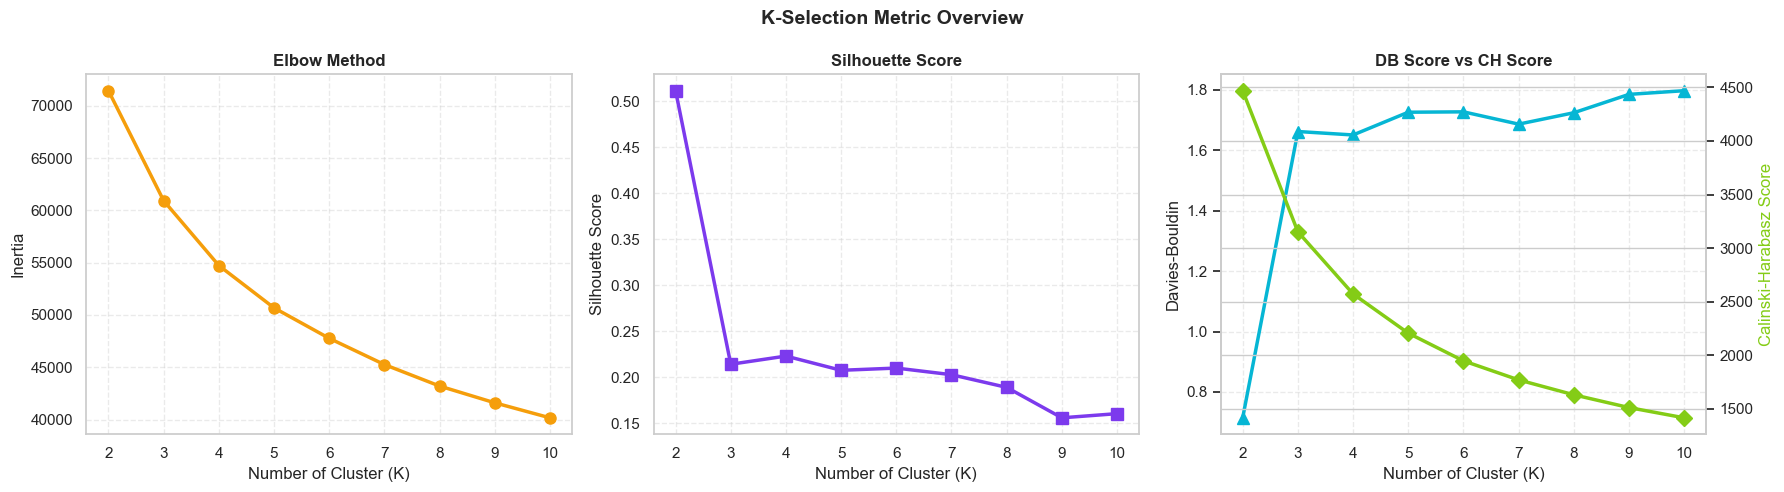

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))
plots = [
    (inertias, 'Inertia', 'Elbow Method', PALETTE[3], 'o'),
    (sil_scores, 'Silhouette Score', 'Silhouette Score', PALETTE[0], 's'),
    (db_scores, 'Davies-Bouldin', 'DB Score vs CH Score', PALETTE[6], '^')
]

for ax, (data, ylabel, title, color, marker) in zip(axes, plots):
    ax.plot(k_list, data, marker=marker, linewidth=2.5, markersize=8, color=color)
    ax.set(title=title, xlabel='Number of Cluster (K)', ylabel=ylabel)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.title.set_fontweight('bold')

ax_ch = axes[2].twinx()
ax_ch.plot(k_list, ch_scores, marker='D', linewidth=2.5, markersize=8, color=PALETTE[7], label='Calinski-Harabasz')
ax_ch.set_ylabel('Calinski-Harabasz Score', color=PALETTE[7])
plt.suptitle("K-Selection Metric Overview", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [25]:
N_CLUSTER = 2
final_kmeans = KMeans(
    n_clusters=N_CLUSTER,
    init='k-means++',
    n_init=10,
    max_iter=300,
    random_state=RANDOM_STATE
)
df['cluster'] = final_kmeans.fit_predict(X_processed)
print(df['cluster'].value_counts(ascending=False))

cluster
1    5350
0     817
Name: count, dtype: int64


### **4. Cluster Evaluation**

In [26]:
def evaluate(X_processed, labels, inertias):
    return{
        'Inertia' : inertias,
        'Silhouette Score' : silhouette_score(X_processed, labels),
        'Davies-Bouldin' : davies_bouldin_score(X_processed, labels),
        'Calinski-Harabasz' : calinski_harabasz_score(X_processed, labels)
    }

result = evaluate(X_processed, df['cluster'], final_kmeans.inertia_)
eval_df = pd.DataFrame([result], index=[f'K={N_CLUSTER}'])
display(eval_df.style.format('{:.4f}').set_caption(f'Cluster Evaluation'))

,Inertia,Silhouette Score,Davies-Bouldin,Calinski-Harabasz
K=2,71436.6343,0.5113,0.7142,4469.6161


### **5. Cluster Profiling**

In [27]:
PROFILE_NUM = ['density_per_kmsq', 'literacy_rate', 'total_population',
               'police_station', 'school', 'heatindex', 'precip',
               'religious_institution', 'playground', 'park', 'college']
PROFILE_CAT = ['incident_division', 'part_of_the_day', 'season', 'crime']

num_profile  = df.groupby('cluster')[PROFILE_NUM].median()
cat_profile  = df.groupby('cluster')[PROFILE_CAT].agg(lambda x: x.mode()[0])
profile_summary = pd.concat([num_profile, cat_profile], axis=1)
display(profile_summary.sort_values('density_per_kmsq', ascending=False).T)

cluster,0,1
density_per_kmsq,30551.0000,1138.0000
literacy_rate,74.6000,52.8000
total_population,8906039.0000,341328.0000
police_station,60.0000,2.0000
school,242.0000,42.0000
heatindex,33.0000,33.0000
precip,0.8000,0.8000
religious_institution,4289.0000,706.0000
playground,99.0000,17.0000
park,17.0000,1.0000


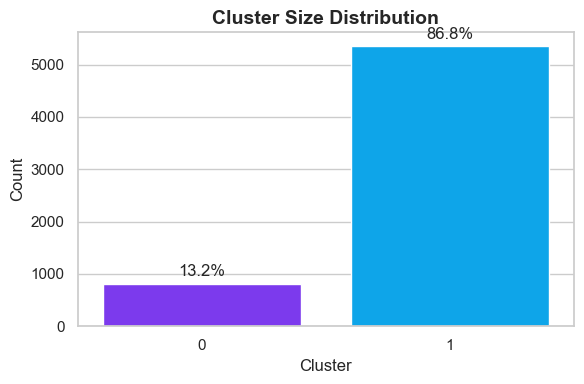

In [28]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x='cluster', data=df, color='#d1d5db')
ax.patches[0].set_facecolor(PALETTE[0])
ax.patches[1].set_facecolor(PALETTE[1])
n = len(df)

for container in ax.containers:
    labels = [f'{v.get_height()/n*100:.1f}%' 
              for v in container]
    ax.bar_label(container, labels=labels, padding=3)
plt.title('Cluster Size Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

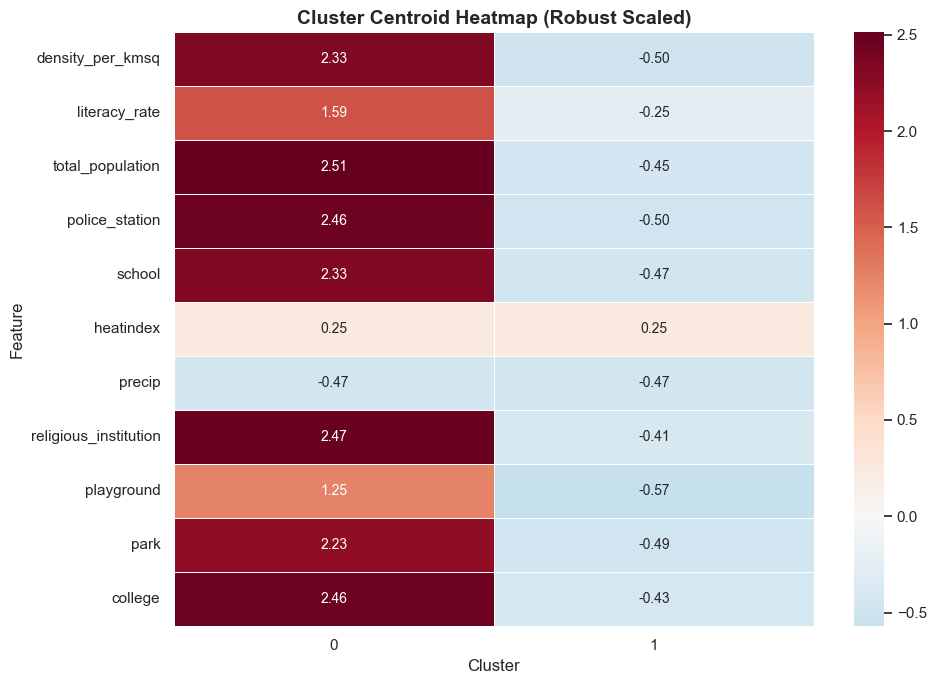

In [29]:
profile_norm = (num_profile - df[PROFILE_NUM].mean()) / df[PROFILE_NUM].std()

plt.figure(figsize=(10, 7))
sns.heatmap(profile_norm.T, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, annot_kws={'size': 10})
plt.title('Cluster Centroid Heatmap (Robust Scaled)', fontsize=14, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

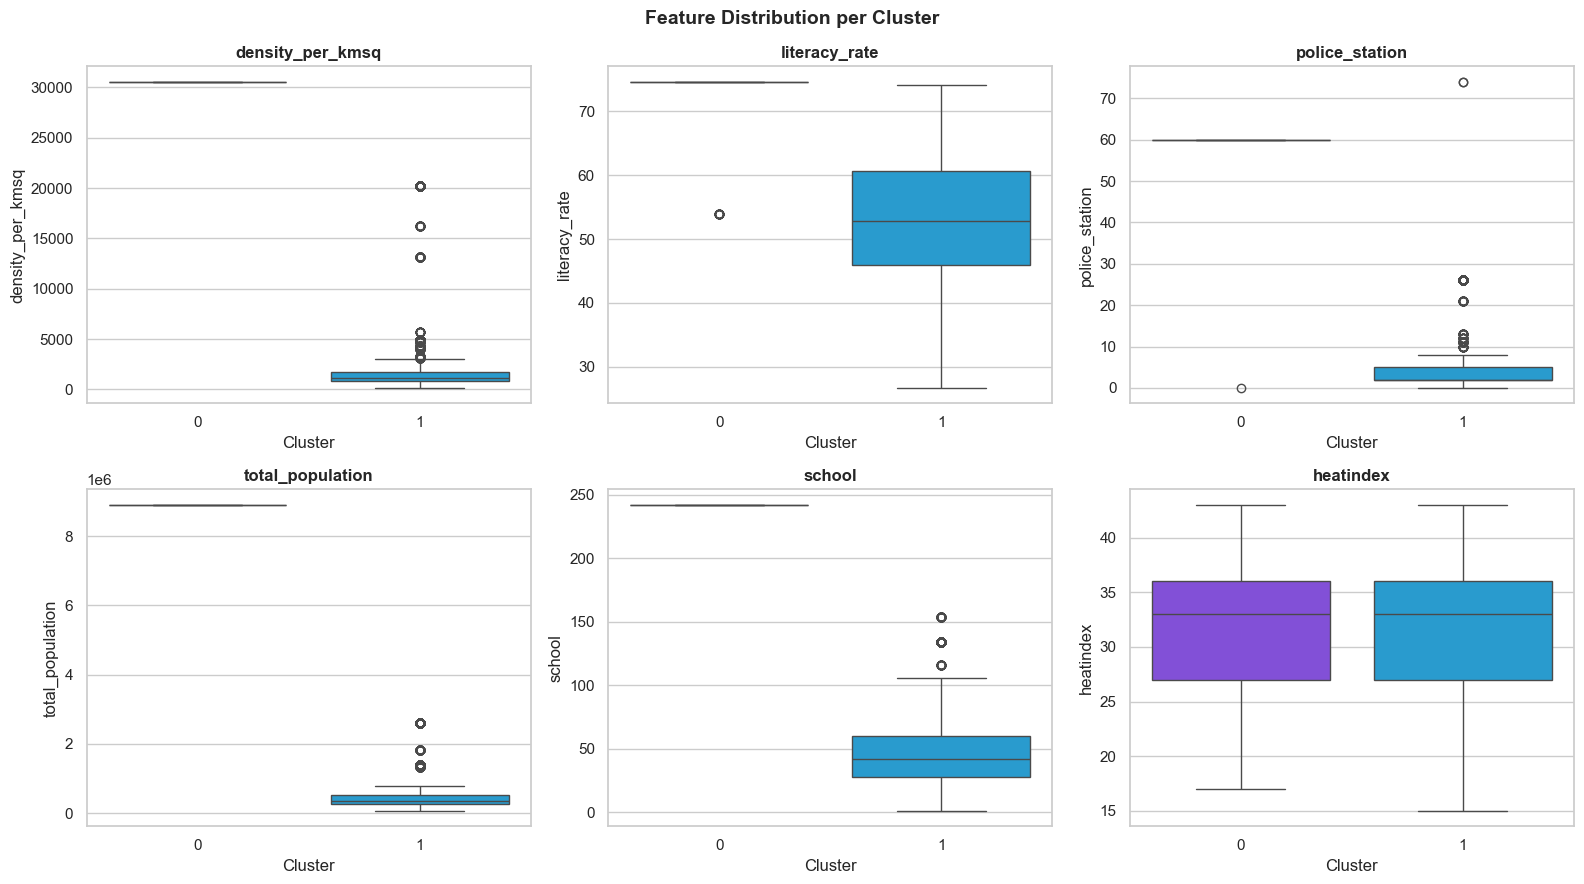

In [30]:
BOX_FEATURES = ['density_per_kmsq', 'literacy_rate', 'police_station',
                'total_population', 'school', 'heatindex']

fig, axes = plt.subplots(2, 3, figsize=(16,9))
for ax, col in zip(axes.flatten(), BOX_FEATURES):
    sns.boxplot(x='cluster', y=col, data=df, palette=PALETTE, ax=ax)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Cluster')

plt.suptitle('Feature Distribution per Cluster', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [31]:
CLUSTER_NAMES = {
    0 : 'Urban Megacity (High Density)',
    1 : 'Rural Frontier (Low Resource)'
}
df['cluster_name'] = df['cluster'].map(CLUSTER_NAMES)
for k, name in CLUSTER_NAMES.items():
    size = (df['cluster'] == k).sum()
    print(f'Cluster {k}: {name} ({size/len(df)*100:.1f}%)')

Cluster 0: Urban Megacity (High Density) (13.2%)
Cluster 1: Rural Frontier (Low Resource) (86.8%)


### **6. Cluster Visualization**

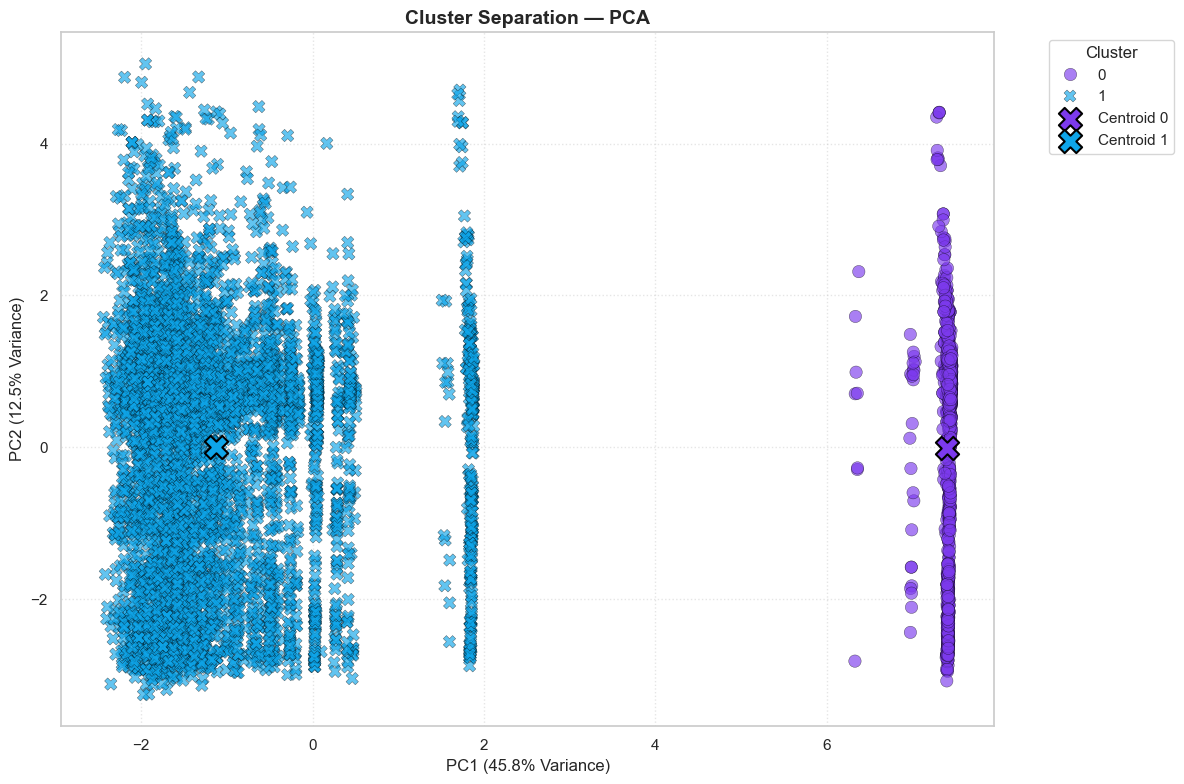

In [32]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_processed)
ev   = pca.explained_variance_ratio_ * 100 

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'], index=df.index)
df_pca['cluster'] = df['cluster'].values
centroids_pca = pca.transform(final_kmeans.cluster_centers_)

plt.figure(figsize=(12, 8))
sns.scatterplot(x='PC1', y='PC2', hue='cluster', style='cluster',
                data=df_pca, palette=PALETTE, s=80, alpha=0.65,
                edgecolor='black', linewidth=0.3)

for i, (cx, cy) in enumerate(centroids_pca):
    plt.scatter(cx, cy, s=280, marker='X', color=PALETTE[i],
                edgecolors='black', linewidths=1.5, zorder=5, label=f'Centroid {i}')

plt.title(f'Cluster Separation — PCA', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({ev[0]:.1f}% Variance)')
plt.ylabel(f'PC2 ({ev[1]:.1f}% Variance)')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1))
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

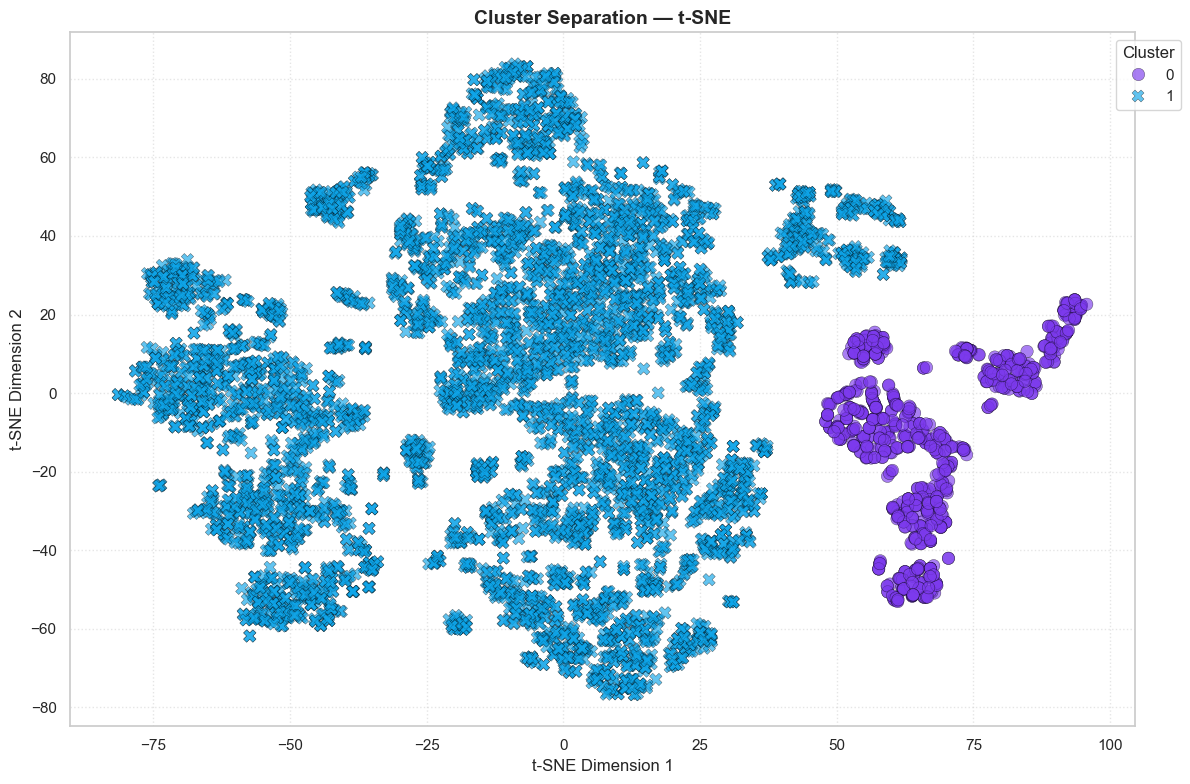

In [33]:
tsne  = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_processed)

df_tsne = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'], index=df.index)
df_tsne['cluster'] = df['cluster'].values

plt.figure(figsize=(12,8))
sns.scatterplot(x='TSNE1', y='TSNE2', hue='cluster', style='cluster',
                data=df_tsne, palette=PALETTE, s=80, alpha=0.65,
                edgecolor='black', linewidth=0.3)
plt.title('Cluster Separation — t-SNE', fontsize=14, fontweight='bold')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.05,1))
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

In [34]:
cross_tab = pd.crosstab(df['cluster'], df['crime'], normalize='index').mul(100).round(2)
print('Crime Type Proportion per Cluster (%)')
display(cross_tab.style.format('{:.2f}'))

Crime Type Proportion per Cluster (%)


crime,assault,bodyfound,kidnap,murder,rape,robbery
cluster,,,,,,
0,17.75,27.78,7.83,14.44,13.95,18.24
1,16.67,22.80,10.17,24.36,18.49,7.51


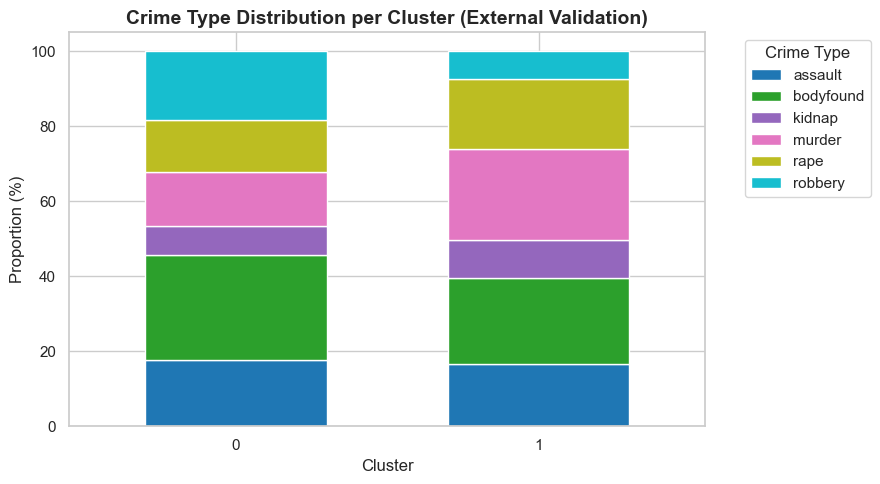

In [35]:
cross_tab.plot(
    kind='bar', stacked=True, figsize=(9, 5),
    colormap='tab10', edgecolor='white', width=0.6
)

plt.title('Crime Type Distribution per Cluster (External Validation)',
          fontsize=14, fontweight='bold')
plt.ylabel('Proportion (%)')
plt.xlabel('Cluster')
plt.xticks(rotation=0)
plt.legend(title='Crime Type', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()